# DOCUMENTATION
- **TODO**
    - So far, I've looked into the transaction banking dataset's inbound vs outbound, but I should merge the other datasets to get a masterlist, then plot and infer.
    - Need to look into models to estimate SoW (Share of Wallet) however some further analysis is required in terms of assumptions to be made and inferences to be noted especially for trade heavy companies with empty accounts at SynBank


In [17]:
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
%matplotlib inline

In [18]:
# Loading the given Data Sets
transactional_data = pd.read_csv("Data/transactional_banking.csv")
cross_border_payments = pd.read_csv("Data/cross_border_payments.csv")
trade_finance = pd.read_csv("Data/trade_finance.csv")

In [19]:
# print(transactional_data.dtypes)
# print(cross_border_payments.dtypes)
# print(trade_finance.dtypes)

print(transactional_data.columns)
print("#" + "="*100 + "#")
transactional_data['amount_zar'] = pd.to_numeric(transactional_data['amount_zar'])
print(cross_border_payments.columns)
print("#" + "="*100 + "#")
print(trade_finance.columns)

Index(['transaction_id', 'entity_id', 'entity_name', 'sector', 'date',
       'leg_type', 'direction', 'amount_zar', 'currency', 'channel',
       'beneficiary_name', 'reference', 'memo'],
      dtype='object')
#====================================================================================================#
Index(['transaction_id', 'entity_id', 'entity_name', 'sector', 'date',
       'direction', 'currency_pair', 'value_zar', 'counterparty_country',
       'corridor_type', 'beneficiary_name', 'reference', 'memo'],
      dtype='object')
#====================================================================================================#
Index(['instrument_id', 'entity_id', 'entity_name', 'sector', 'date',
       'instrument_type', 'direction', 'tenor_days', 'value_zar',
       'counterparty_country', 'commodity_or_contract_type', 'status',
       'beneficiary_name', 'reference', 'memo'],
      dtype='object')


In [20]:
# All the companies captured by Syn Bank's records
print(transactional_data['entity_name'].unique())

['BHP Group' 'Pepkor Holdings' 'Anglo American' 'Glencore'
 'AngloGold Ashanti' 'Sanlam' 'Gold Fields' 'MTN Group' 'Vodacom Group'
 'The Bidvest Group' 'Aspen Pharmacare' 'Clicks Group' 'Naspers' 'Prosus'
 'Shoprite Holdings' 'Bid Corporation' 'Valterra Platinum'
 'OUTsurance Group' 'NEPI Rockcastle' 'Shaftesbury Capital plc']


In [21]:
# Confirmation that all data sets capture the same number of companies
print(transactional_data['entity_name'].nunique())
print(cross_border_payments['entity_name'].nunique())
print(trade_finance['entity_name'].nunique())

20
20
20


In [22]:
# Retrieving total inbound and outbound finances per company per dataset  # Sets amount to numeric
transaction_flow = transactional_data.pivot_table(
    index = 'entity_name', 
    columns = 'direction', 
    values = 'amount_zar', 
    aggfunc = 'sum',
    fill_value = 0
)
transaction_flow['Total_Volume'] = transaction_flow.sum(axis = 1)

print(transaction_flow)

direction                     inbound      outbound  Total_Volume
entity_name                                                      
Anglo American           1.922971e+10  7.023449e+09  2.625316e+10
AngloGold Ashanti        3.956126e+09  1.573672e+09  5.529798e+09
Aspen Pharmacare         5.243497e+09  4.480908e+09  9.724405e+09
BHP Group                3.426295e+10  1.244308e+10  4.670604e+10
Bid Corporation          1.815278e+10  1.522749e+10  3.338026e+10
Clicks Group             2.787347e+08  3.139147e+08  5.926494e+08
Glencore                 9.155433e+09  3.397379e+09  1.255281e+10
Gold Fields              3.432490e+09  1.348374e+09  4.780864e+09
MTN Group                1.715076e+10  1.437334e+10  3.152410e+10
NEPI Rockcastle          5.392701e+07  6.286567e+07  1.167927e+08
Naspers                  2.237189e+09  1.978571e+09  4.215761e+09
OUTsurance Group         4.063891e+08  4.654209e+08  8.718100e+08
Pepkor Holdings          5.642597e+10  4.699384e+10  1.034198e+11
Prosus    

In [23]:
# Baseline Statistics for a feel of the data
stats_by_company = transactional_data.groupby(['entity_name', 'direction'])['amount_zar'].describe()
print(stats_by_company)

                                      count           mean           std  \
entity_name             direction                                          
Anglo American          inbound     49798.0  386154.205770  6.438774e+05   
                        outbound    44737.0  156994.197699  4.156830e+05   
AngloGold Ashanti       inbound     12382.0  319506.193084  5.713277e+05   
                        outbound    11533.0  136449.502097  3.860123e+05   
Aspen Pharmacare        inbound     55898.0   93804.727991  2.389081e+05   
                        outbound    51174.0   87562.207467  2.409297e+05   
BHP Group               inbound     65922.0  519749.883443  9.171351e+05   
                        outbound    59350.0  209656.000127  5.881326e+05   
Bid Corporation         inbound    116402.0  155949.001801  3.784956e+05   
                        outbound   106899.0  142447.421801  3.756821e+05   
Clicks Group            inbound      3774.0   73856.573378  1.290666e+05   
            

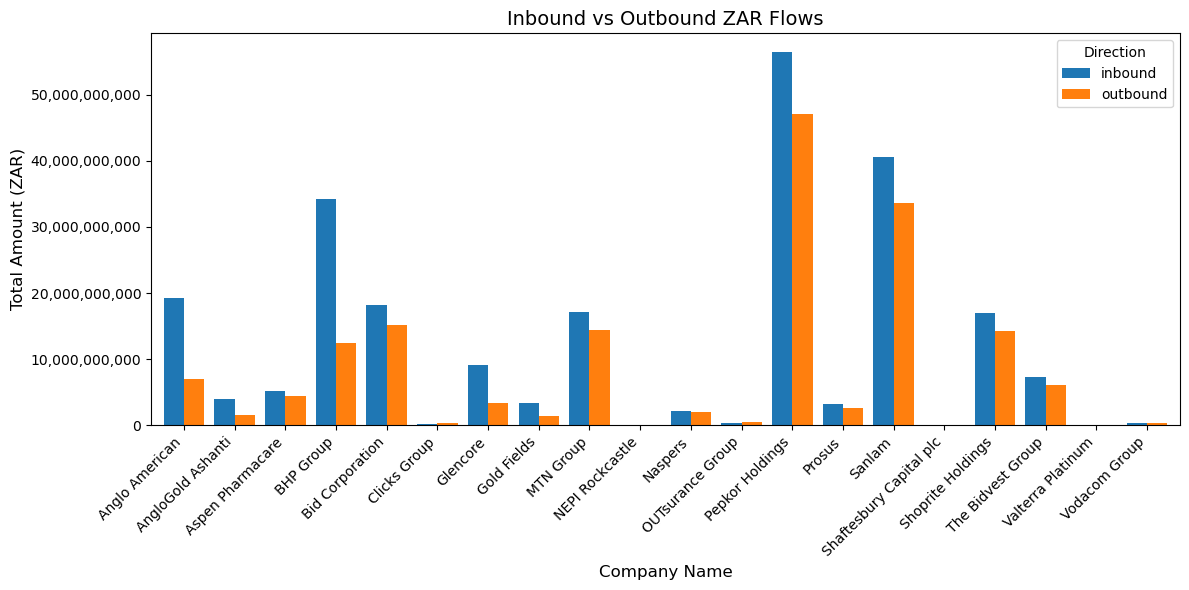

In [24]:
# Plotting the flows
transaction_flow_plot = transaction_flow.drop(columns = 'Total_Volume')
ax = transaction_flow_plot.plot(kind = 'bar', figsize = (12, 6), width = 0.8, color = ['#1f77b4', '#ff7f0e'])

plt.title('Inbound vs Outbound ZAR Flows', fontsize = 14)
plt.xlabel('Company Name', fontsize = 12)
plt.ylabel('Total Amount (ZAR)', fontsize = 12)

# Rotate x-axis labels so company names are readable
plt.xticks(rotation = 45, ha = 'right')

# Format the y-axis to show standard numbers instead of scientific notation (e.g., 1e8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(title = 'Direction')
plt.tight_layout()
plt.show()